# 05 — H5 darkness vs tenderness audit (human review)

Focused boundaries only: `7.3` (external?), `3.2` (relational?), tenderness via H1/H4
reuse. Do **not** fully relabel `7.2` / `4.4` (already high on-label fidelity in Stage 10
NB07) — those leaves stay as known-good anchors.

Saved audits + packets only; rating cells stay blinded.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code
from src.stage11_refined_construct_analysis.lookup import load_topic_lookup, topics_for_leaves

ctx = nh.setup("05_h5_darkness_tenderness_audit")
cfg = ctx.cfg
HYP = "H5"
CODE_COL = "darkness_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit


## 1. Overview — H5-coded topics with labels

In [2]:
lookup = load_topic_lookup(cfg)
master = nh.load_master(cfg)
h5 = master[master[CODE_COL].notna()].copy()
h5["code_norm"] = h5[CODE_COL].map(normalize_code)
print(f"H5-coded topics: {len(h5)}")

overview = rd.annotation_overview(
    h5, CODE_COL, extra_cols=["main_couple_prob"]
)
display(
    overview[
        ["topic", "taxonomy", "code", "code_norm", "mixed", "main_couple_prob"]
    ]
)
ctx.save_table(overview, "h5_topic_overview_labeled")
display(h5[CODE_COL].value_counts().to_frame("n"))
display(h5["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

skip = set(topics_for_leaves(lookup, ["7.2", "4.4"]))
print(f"Topics deliberately not fully relabelled (7.2∪4.4): {len(skip)}")
print("Skip pool (id — label), first 12:")
for line in rd.labeled_topic_list(lookup, sorted(skip)[:12]):
    print(f"  · {line}")
print(f"Of which appear in H5 audit anyway: {h5['topic_id'].isin(skip).sum()}")

H5-coded topics: 22


,topic,taxonomy,code,code_norm,mixed,main_couple_prob
0,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
1,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,D4,D4,False,0.0000
2,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
3,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
4,133 — Holding Back Tears,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
5,145 — Confessing How Much It Hurts,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
6,152 — Awkward Apology and Embarrassment,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
7,179 — Dreading What You Stand to Lose,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.8500
8,220 — Called Out For Being Embarrassing,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000
9,244 — Confessing A Shattered Heart,3.2 — Negative Emotions & Distress,UNKNOWN,None,False,0.0000


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit/tables/h5_topic_overview_labeled.csv  (22 rows)


,n
darkness_code,
UNKNOWN,21
D4,1


,n_norm
code_norm,
None,21
D4,1


Topics deliberately not fully relabelled (7.2∪4.4): 20
Skip pool (id — label), first 12:
  · 3 — Demanding An Explanation
  · 24 — Confronting An Unwanted Marriage
  · 43 — Pissed Off and Grumbling
  · 51 — Locked Up By A Vampire
  · 78 — Swearing War Before He Takes Her
  · 82 — Touch Her and Your Family Suffers
  · 85 — Offering and Refusing An Apology
  · 87 — Threatening Death As A Warning
  · 113 — Knife Handed Over For Combat
  · 114 — Guns Aimed Across The Room
  · 117 — Blamed and Threatened Into Compliance
  · 129 — Accused of Not Caring
Of which appear in H5 audit anyway: 0


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h5, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h5_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    if len(disagree):
        display(
            disagree[
                ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_c"]
            ]
        )

Lexical–contextual agreement: 4.5% (1/22)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit/tables/h5_lexical_contextual_agreement.csv  (22 rows)


,topic,taxonomy,code_a,code_b,code_c,rationale_c
1,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,H5,relational_darkness_individual_distress_tie,UNKNOWN,
2,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,fear_anxiety,D4,D4,
3,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,H5,D_individual,UNKNOWN,
4,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,102,CELL_B,UNKNOWN,
5,133 — Holding Back Tears,3.2 — Negative Emotions & Distress,individual_distress,ID,UNKNOWN,
6,145 — Confessing How Much It Hurts,3.2 — Negative Emotions & Distress,H5,individual_distress,UNKNOWN,
7,152 — Awkward Apology and Embarrassment,3.2 — Negative Emotions & Distress,tenderness,CELL_B,UNKNOWN,
8,179 — Dreading What You Stand to Lose,3.2 — Negative Emotions & Distress,179,ID,UNKNOWN,
9,184 — Racing to Stop A Spreading Fire,"7.3 — Risk, Danger & External Crises",H5_184_fire_and_flames,H5,UNKNOWN,
10,220 — Called Out For Being Embarrassing,3.2 — Negative Emotions & Distress,H5,CELL_B,UNKNOWN,


## 3. Tenderness reuse from H1 / H4

These are candidates for `tenderness_core` — verify a sample of labels, not just codes.

In [4]:
tender_h1 = master[master["intimacy_code"].map(normalize_code).isin(["I1", "I2", "I3"])]
tender_h4 = master[
    master["care_protection_code"].map(normalize_code).isin(["H4_1", "H4_12"])
]
print(f"H1 affection/reassurance candidates for tenderness_core: {len(tender_h1)}")
print(f"H4 reassurance/reciprocal candidates: {len(tender_h4)}")
t1 = rd.annotation_overview(tender_h1.assign(code_norm=tender_h1["intimacy_code"].map(normalize_code)), "intimacy_code")
display(t1[["topic", "taxonomy", "code", "code_norm"]].head(25))
ctx.save_table(
    tender_h1[
        ["topic_id", "current_topic_label", "intimacy_code", "current_taxonomy_id"]
    ],
    "h5_tenderness_from_h1",
)

H1 affection/reassurance candidates for tenderness_core: 34
H4 reassurance/reciprocal candidates: 0


,topic,taxonomy,code,code_norm
0,19 — Legs Wrapped Around His Waist,2.1 — Attraction & Sexual Tension,I3,I3
1,352 — Daring Someone to Try,2.1 — Attraction & Sexual Tension,I2,I2
2,101 — Smoothing Loose Strands of Hair,2.2 — Kissing & Non-Explicit Affection,I3,I3
3,124 — Scooped Up in A Tight Hug,2.2 — Kissing & Non-Explicit Affection,I3,I3
4,126 — Fingertips Stroking Her Cheek,2.2 — Kissing & Non-Explicit Affection,I3,I3
5,38 — Admitting Shared Pain,4.2 — Ongoing Courtship & Everyday Relational ...,I2,I2
6,232 — Conversation Cut Short By Arrival,4.2 — Ongoing Courtship & Everyday Relational ...,I2,I2
7,37 — Defending A Close Friendship,"4.3 — Secrets, Misunderstandings & Hidden Info...",I1,I1
8,85 — Offering and Refusing An Apology,"4.4 — Conflict, Distance & Breakup Threats",I2,I2
9,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",I1,I1


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit/tables/h5_tenderness_from_h1.csv  (34 rows)


## 4. Focus leaves `7.3` and `3.2`

What to check: is `7.3` danger outside the couple? Is `3.2` relational darkness rather
than external plot threat? Main-couple probability on the overview is a hint; sentences
decide.

In [5]:
focus = h5[h5["current_taxonomy_id"].isin(["7.3", "3.2"])]
focus_ov = rd.annotation_overview(focus, CODE_COL, extra_cols=["main_couple_prob"])
display(
    focus_ov[
        ["topic", "taxonomy", "code", "code_norm", "main_couple_prob"]
    ]
)
ctx.save_table(focus_ov, "h5_focus_leaves")

,topic,taxonomy,code,code_norm,main_couple_prob
0,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
1,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,D4,D4,0.0000
2,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
3,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
4,133 — Holding Back Tears,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
5,145 — Confessing How Much It Hurts,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
6,152 — Awkward Apology and Embarrassment,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
7,179 — Dreading What You Stand to Lose,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.8500
8,220 — Called Out For Being Embarrassing,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000
9,244 — Confessing A Shattered Heart,3.2 — Negative Emotions & Distress,UNKNOWN,None,0.0000


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit/tables/h5_focus_leaves.csv  (22 rows)


## 5. Close reading

Close-reading 22 of 22 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 27 — Racing The Approaching Storm
  Taxonomy : 7.3 — Risk, Danger & External Crises
  Code     : UNKNOWN
  Stage08 snippets:
      · it’ll be dark before we know it.’’
      · i don’t know if i’ll be able to get back here before the storm hits.
      · it’s going to rain and we’ll be caught out in the storm.
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=end, p=0.52]
        Their lips met, and an explosion of passion took them along on a tide, the darkness
        that surrounded them like a blanket against the rest of the world.
    · [BOOK_001, CELL_D, tertile=begin, p=0.46]
        Just as they reached the spot a man strode angrily out of a neighbouring field, and
        even in the poor light his expression could be seen as thunderous.
    · [BOOK_001, CELL_D, tertile=begin, p=0.44]
        They were still driving, the high hedges making it impossible for them to see
        anything

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/05_h5_darkness_tenderness_audit/figures/h5_code_distribution.png


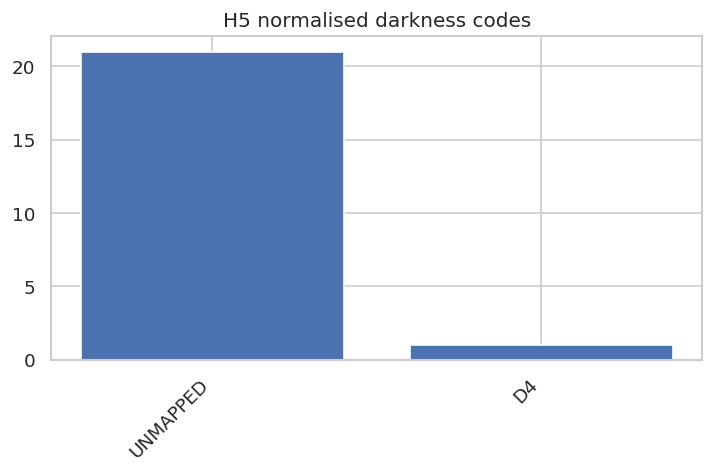

H5 audit review complete.


In [6]:
review_ids = rd.select_review_topics(
    h5,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=focus["topic_id"].tolist(),
    per_code=3,
    seed=42,
    show_all_if_n_le=24,
)
packs = rd.show_review_set(
    cfg,
    h5,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(
        packs, title="H5 darkness / tenderness — close-reading pack"
    ),
    "close_reading_pack",
)
ctx.save_table(
    h5[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "darkness_code",
            "code_norm",
            "main_couple_prob",
        ]
    ],
    "darkness_topic_annotations",
)

fig, ax = plt.subplots(figsize=(7, 3.5))
vc = h5["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H5 normalised darkness codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h5_code_distribution")
plt.show()

print("H5 audit review complete.")